# Motor de búsqueda y clasificador de sentimiento con Deep Learning

<div style="border:2px solid lightgreen; padding:10px; border-radius:5px; background-color:#ECFEEA;">
<strong>Estado:</strong> Terminado.
</div>

In [1]:
import pandas as pd
import numpy as np
import torch

from transformers import BertModel, BertTokenizer
model = BertModel.from_pretrained('bert-base-uncased', output_hidden_states = True,)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
def bert_text_preparation(text, tokenizer):
    """
    Preprocesses text input in a way that BERT can interpret.
    """
    marked_text = "[CLS] " + text + " [SEP]"
    tokenized_text = tokenizer.tokenize(marked_text)
    indexed_tokens = tokenizer.convert_tokens_to_ids(tokenized_text)
    segments_ids = [1]*len(indexed_tokens)
    # convert inputs to tensors
    tokens_tensor = torch.tensor([indexed_tokens])
    segments_tensor = torch.tensor([segments_ids])
    return tokenized_text, tokens_tensor, segments_tensor

In [3]:
def get_bert_embeddings(tokens_tensor, segments_tensor, model):
    """
    Obtains BERT embeddings for tokens.
    """
    # gradient calculation id disabled
    with torch.no_grad():
      # obtain hidden states
      outputs = model(tokens_tensor, segments_tensor)
      hidden_states = outputs[2]
    # concatenate the tensors for all layers
    # use "stack" to create new dimension in tensor
    token_embeddings = torch.stack(hidden_states, dim=0)
    # remove dimension 1, the "batches"
    token_embeddings = torch.squeeze(token_embeddings, dim=1)
    # swap dimensions 0 and 1 so we can loop over tokens
    token_embeddings = token_embeddings.permute(1,0,2)
    # intialized list to store embeddings
    token_vecs_sum = []
    # "token_embeddings" is a [Y x 12 x 768] tensor
    # where Y is the number of tokens in the sentence
    # loop over tokens in sentence
    for token in token_embeddings:
    # "token" is a [12 x 768] tensor
    # sum the vectors from the last four layers
        sum_vec = torch.sum(token[-4:], dim=0)
        token_vecs_sum.append(sum_vec)
    return token_vecs_sum

In [4]:
from collections import OrderedDict

sentences = ["bank",
         "he eventually sold the shares back to the bank at a premium.",
         "the bank strongly resisted cutting interest rates.",
         "the bank will supply and buy back foreign currency.",
         "the bank is pressing us for repayment of the loan.",
         "the bank left its lending rates unchanged.",
         "the river flowed over the bank.",
         "tall, luxuriant plants grew along the river bank.",
         "his soldiers were arrayed along the river bank.",
         "wild flowers adorned the river bank.",
         "two fox cubs romped playfully on the river bank.",
         "the jewels were kept in a bank vault.",
         "you can stow your jewellery away in the bank.",
         "most of the money was in storage in bank vaults.",
         "the diamonds are shut away in a bank vault somewhere.",
         "thieves broke into the bank vault.",
         "can I bank on your support?",
         "you can bank on him to hand you a reasonable bill for your services.",
         "don't bank on your friends to help you out of trouble.",
         "you can bank on me when you need money.",
         "i bank on your help."]

context_embeddings = []
context_tokens = []

for sentence in sentences:
    tokenized_text, tokens_tensor, segments_tensors = bert_text_preparation(sentence, tokenizer)
    list_token_embeddings = get_bert_embeddings(tokens_tensor, segments_tensors, model)
    # make ordered dictionary to keep track of the position of each   word
    tokens = OrderedDict()
    # loop over tokens in sensitive sentence
    for token in tokenized_text[1:-1]:
        # keep track of position of word and whether it occurs multiple times
        if token in tokens:
          tokens[token] += 1
        else:
          tokens[token] = 1
    # compute the position of the current token
    token_indices = [i for i, t in enumerate(tokenized_text) if t == token]
    current_index = token_indices[tokens[token]-1]
    # get the corresponding embedding
    token_vec = list_token_embeddings[current_index]

    # save values
    context_tokens.append(token)
    context_embeddings.append(token_vec)

In [5]:
context_embeddings[0].size()

torch.Size([768])

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Aplanar los tensores y convertirlos a NumPy
representaciones_np = [tensor.detach().numpy().flatten() for tensor in context_embeddings]
representaciones_np = np.stack(representaciones_np)

# Aplicar t-SNE
# Ajustar la perplexity si es necesario
perplexity_value = min(30, len(representaciones_np) - 1)  # Asegúrate de que no sea mayor que el número de muestras
tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity_value)
representaciones_2d = tsne.fit_transform(representaciones_np)

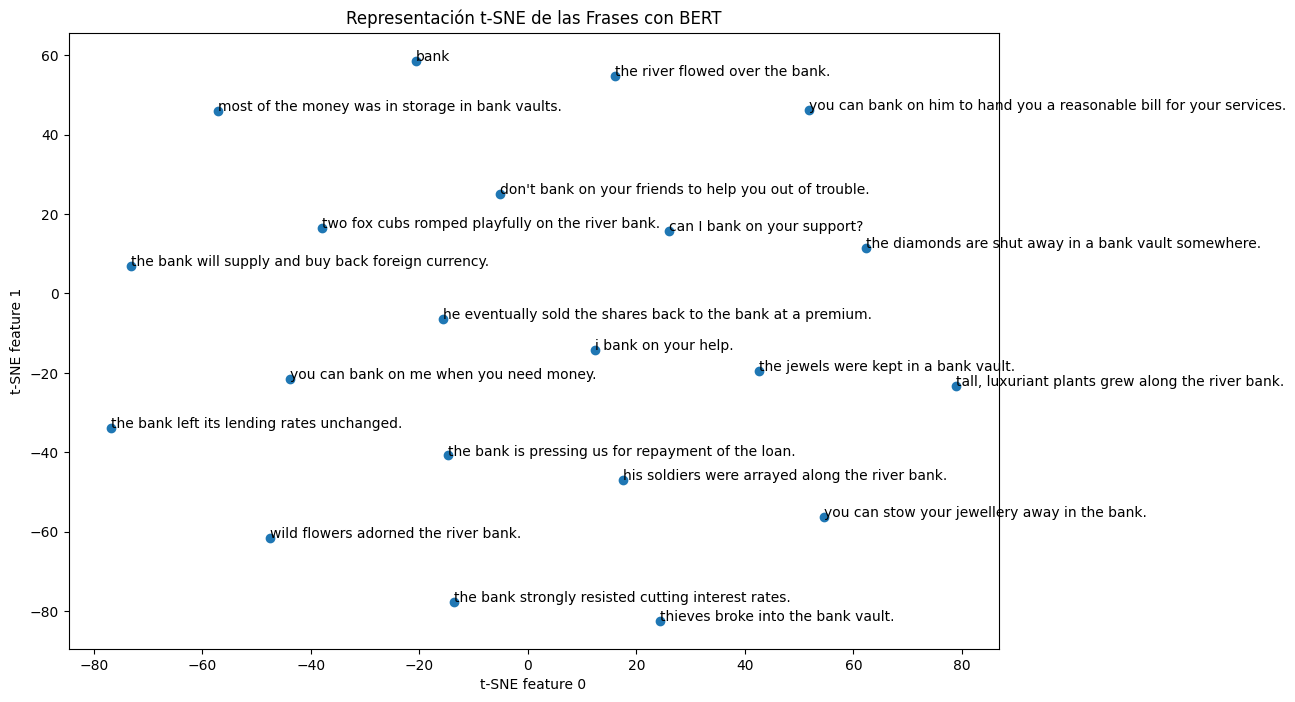

In [7]:
plt.figure(figsize=(12, 8))
plt.scatter(representaciones_2d[:, 0], representaciones_2d[:, 1])

# Opcional: Añadir etiquetas de texto a cada punto
for i, frase in enumerate(sentences):
    plt.annotate(frase, (representaciones_2d[i, 0], representaciones_2d[i, 1]))

plt.xlabel('t-SNE feature 0')
plt.ylabel('t-SNE feature 1')
plt.title('Representación t-SNE de las Frases con BERT')
plt.show()

Las primeras celdas muestran un ejemplo juguete con la palabra **bank** para ilustrar cómo BERT cambia su representación según el contexto. El flujo principal del notebook empieza más abajo, donde aplicamos el mismo enfoque a las reseñas del dataset de hoteles.

## Motor de búsqueda con BERT

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)

from utilities.searcher import TextBERTSearchPipeline


In [9]:
df_reviews = pd.read_csv("Datasets/tripadvisor_hotel_reviews.csv")[["Review", "Rating"]].copy()
df_reviews["Review"] = df_reviews["Review"].astype(str).str.strip()
df_reviews = df_reviews[df_reviews["Review"].str.len() > 0].dropna().reset_index(drop=True)

In [10]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased", output_hidden_states=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
def encode_texts_bert(texts, batch_size=32, max_length=128):
    device = torch.device(
        "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
    )
    model.to(device)
    model.eval()

    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        encoded = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)

        stacked_last4 = torch.stack(outputs.hidden_states[-4:], dim=0).sum(dim=0)
        attention_mask = encoded["attention_mask"].unsqueeze(-1)
        masked = stacked_last4 * attention_mask
        token_count = attention_mask.sum(dim=1).clamp(min=1)
        sentence_embeddings = masked.sum(dim=1) / token_count

        all_embeddings.append(sentence_embeddings.cpu().numpy().astype(np.float32))

    return np.vstack(all_embeddings)

In [12]:
reviews_list = df_reviews["Review"].tolist()
bert_embeddings = encode_texts_bert(reviews_list, batch_size=32, max_length=128)

bert_embeddings.shape

(20491, 768)

In [13]:
def encode_single_query(query_text):
    return encode_texts_bert([query_text], batch_size=1, max_length=128)[0]


text_search = TextBERTSearchPipeline(
    embeddings=bert_embeddings,
    reviews_df=df_reviews,
    query_encoder=encode_single_query,
    metric="cosine",
)

queries_test = [
    "clean and comfortable room",
    "bad service",
    "excellent pool",
    "dirty bathroom",
    "friendly staff",
    "poor location",
    "great breakfast",
    "noisy rooms",
]

print("RESULTADOS DEL BUSCADOR BERT\n")
for query in queries_test:
    top = text_search.search(query, top_k=3)
    print(f"Query: '{query}'")
    for _, row in top.iterrows():
        preview = row["review"][:120].replace("\n", " ")
        print(
            f"  {int(row['rank'])}. dist={row['distance']:.4f} sim={row['similarity']:.4f} "
            f"rating={row['rating']:.1f} | {preview}...", end="\n"
        )
    print()

RESULTADOS DEL BUSCADOR BERT

Query: 'clean and comfortable room'
  1. dist=0.2149 sim=0.7851 rating=5.0 | amazing, perfect location staff friendly.this hotel exceptionally clean fresh towels clean sheets clean bathroom, amazin...
  2. dist=0.2310 sim=0.7690 rating=5.0 | perfect, impressive place, want clean comfy rooms great location, pleased,...
  3. dist=0.2329 sim=0.7671 rating=5.0 | great location beautiful hotel best location, bathrooms bedrooms awesome beds like sleeping slab, staff excellent,...

Query: 'bad service'
  1. dist=0.3199 sim=0.6801 rating=3.0 | transport good class high excellent communications course makes prime choice conferences similar, nice class good staff,...
  2. dist=0.3232 sim=0.6768 rating=5.0 | nice great friendly service clean shuttle service city centre half hour useful, wonderful facilities, surprisingly cheap...
  3. dist=0.3287 sim=0.6713 rating=3.0 | decent hotel poor location price good room far stay, staff desk rude/condescending,...

Query: 'ex

Accuracy:  0.9222
Precision: 0.9196
Recall:    0.9222
F1-score:  0.9205


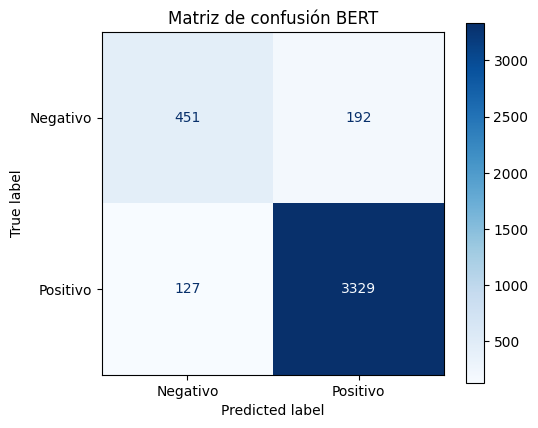

In [14]:
df_reviews["label"] = (df_reviews["Rating"] >= 3).astype(int)

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    bert_embeddings,
    df_reviews["label"].to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=df_reviews["label"].to_numpy(),
)

clf_bert = LogisticRegression(max_iter=1000, random_state=42)
clf_bert.fit(X_train_bert, y_train_bert)

y_pred_bert = clf_bert.predict(X_test_bert)

accuracy_bert = accuracy_score(y_test_bert, y_pred_bert)
precision_bert = precision_score(y_test_bert, y_pred_bert, average="weighted")
recall_bert = recall_score(y_test_bert, y_pred_bert, average="weighted")
f1_bert = f1_score(y_test_bert, y_pred_bert, average="weighted")

print(f"Accuracy:  {accuracy_bert:.4f}")
print(f"Precision: {precision_bert:.4f}")
print(f"Recall:    {recall_bert:.4f}")
print(f"F1-score:  {f1_bert:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test_bert,
    y_pred_bert,
    display_labels=["Negativo", "Positivo"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Matriz de confusión BERT")
plt.tight_layout()
plt.show()

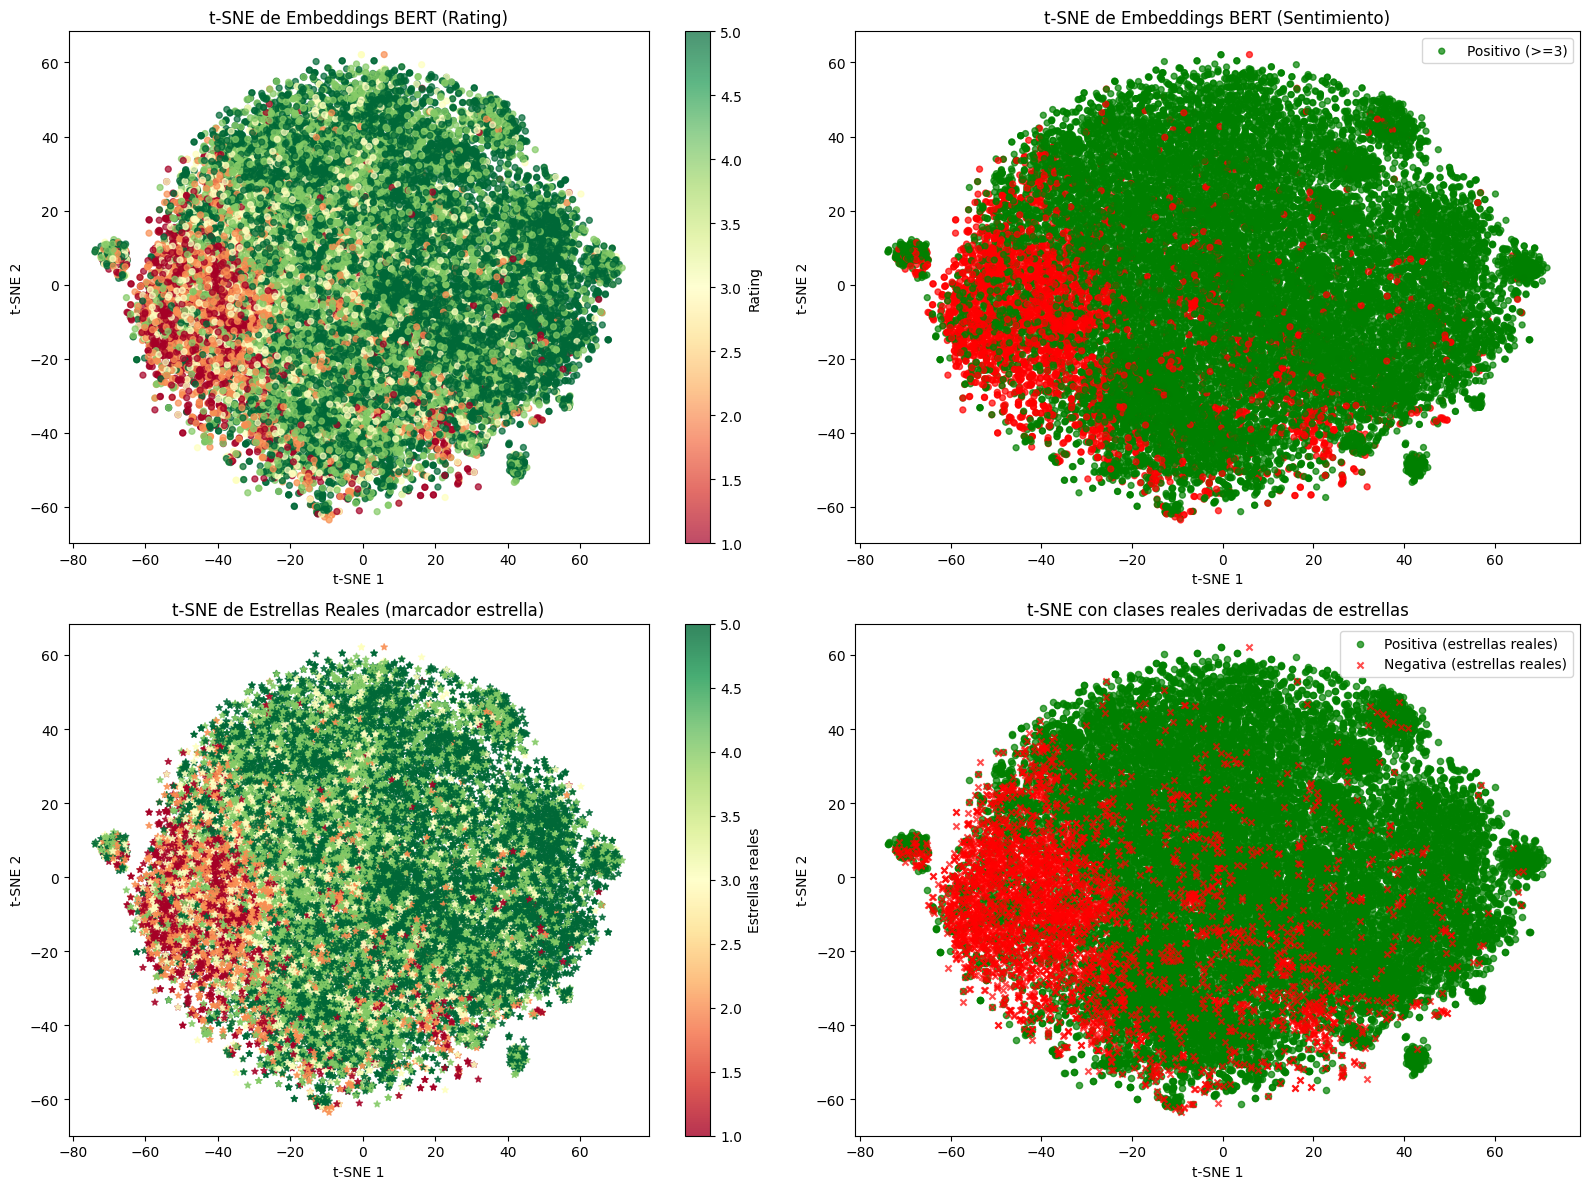

In [15]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne_idx = np.arange(len(df_reviews))

X_bert_tsne_input = bert_embeddings[tsne_idx]
df_tsne = df_reviews.iloc[tsne_idx].reset_index(drop=True)

perplexity = min(30, max(5, len(X_bert_tsne_input) // 20))
tsne_bert = TSNE(n_components=2, random_state=42, perplexity=perplexity)
X_bert_tsne = tsne_bert.fit_transform(X_bert_tsne_input)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()
rating_cmap = "RdYlGn"
sentiment_colors = {"Positivo": "green", "Negativo": "red"}

scatter1 = axes[0].scatter(
    X_bert_tsne[:, 0], X_bert_tsne[:, 1], c=df_tsne["Rating"], cmap=rating_cmap, alpha=0.7, s=18
)
axes[0].set_title("t-SNE de Embeddings BERT (Rating)")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label("Rating")

sentimientos = np.where(df_tsne["Rating"] >= 3, "Positivo", "Negativo")
colores = [sentiment_colors[s] for s in sentimientos]
axes[1].scatter(X_bert_tsne[:, 0], X_bert_tsne[:, 1], c=colores, alpha=0.7, s=18)
axes[1].set_title("t-SNE de Embeddings BERT (Sentimiento)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(["Positivo (>=3)", "Negativo (<3)"], loc="best")

scatter3 = axes[2].scatter(
    X_bert_tsne[:, 0], X_bert_tsne[:, 1], c=df_tsne["Rating"], cmap=rating_cmap, alpha=0.8, s=22, marker="*"
)
axes[2].set_title("t-SNE de Estrellas Reales (marcador estrella)")
axes[2].set_xlabel("t-SNE 1")
axes[2].set_ylabel("t-SNE 2")
cbar3 = plt.colorbar(scatter3, ax=axes[2])
cbar3.set_label("Estrellas reales")

rating_labels = np.where(df_tsne["Rating"] >= 3, "Positiva", "Negativa")
marker_map = {"Positiva": "o", "Negativa": "x"}
for label in ["Positiva", "Negativa"]:
    mask = rating_labels == label
    axes[3].scatter(
        X_bert_tsne[mask, 0],
        X_bert_tsne[mask, 1],
        alpha=0.7,
        s=20,
        marker=marker_map[label],
        c=sentiment_colors["Positivo"] if label == "Positiva" else sentiment_colors["Negativo"],
        label=f"{label} (estrellas reales)",
    )
axes[3].set_title("t-SNE con clases reales derivadas de estrellas")
axes[3].set_xlabel("t-SNE 1")
axes[3].set_ylabel("t-SNE 2")
axes[3].legend(loc="best")

plt.tight_layout()
plt.show()

## Conclusiones

En este notebook hemos trabajado con representaciones contextuales de BERT aplicadas a reseñas de hoteles. La idea principal es que una palabra o una reseña no se interpreta solo por las palabras que contiene, sino por el contexto completo en el que aparece. Por eso BERT resulta especialmente útil tanto para búsqueda semántica como para clasificación de sentimiento.

El motor de búsqueda no se limita a encontrar coincidencias literales, sino que recupera reseñas con un significado parecido a la consulta. Eso se nota mejor cuando la query expresa una idea y no una palabra exacta, porque las respuestas relevantes no siempre comparten vocabulario, pero sí intención.

La visualización t-SNE ayuda a ver que las reseñas no están distribuidas al azar en el espacio de embeddings. Aunque la proyección a dos dimensiones simplifica mucho la información, sí se aprecia cierta estructura coherente entre reseñas parecidas y entre clases de sentimiento.

Como limitación principal, este enfoque requiere más tiempo de cálculo que métodos clásicos más ligeros, porque generar embeddings con BERT es costoso. Aun así, cuando se busca calidad semántica en recuperación de información o clasificación, el coste compensa.